In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np
from ipycanvas import Canvas
from ipywidgets import VBox, HBox, Button, IntText, Output, Label

In [ ]:
# Canvas (560x560 für 16x16 Raster)
canvas = Canvas(width=560, height=560, sync_image_data=True)

canvas_size = 560
canvas = Canvas(width=canvas_size, height=canvas_size, sync_image_data=True)

# Canvas auf weiß setzen
canvas.fill_style = 'white'
canvas.fill_rect(0, 0, 560, 560)
canvas.stroke_style = '#333'
canvas.line_cap = 'round'
canvas.line_join = 'round'

# Zeichnen-Status
drawing = False
x_prev, y_prev = 0, 0

def on_mouse_down(x, y):
    global drawing, x_prev, y_prev
    drawing = True
    x_prev, y_prev = x, y

def on_mouse_move(x, y):
    global x_prev, y_prev
    if drawing:
        canvas.stroke_style = 'black'
        canvas.line_width = 25
        canvas.stroke_line(x_prev, y_prev, x, y)
        x_prev, y_prev = x, y

def on_mouse_up(x, y):
    global drawing
    drawing = False

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

# Canvas -> 16x16 Graustufen (1–16)
def canvas_to_16x16():
    GRID = 16
    W, H = canvas.width, canvas.height
    cell_w, cell_h = W / GRID, H / GRID
    
    img = canvas.get_image_data(0, 0, W, H)  # [H, W, 4] [web:51]
    arr = np.array(img)
    rgb = arr[..., :3].astype(np.float32)
    
    gray = rgb.mean(axis=2) / 255.0     # 0–1 (weiß)
    intensity = 1.0 - gray             # 0–1 (schwarz)

    features = np.zeros((GRID, GRID), dtype=np.int32)

    for gy in range(GRID):
        for gx in range(GRID):
            y0 = int(gy * cell_h)
            y1 = int((gy + 1) * cell_h)
            x0 = int(gx * cell_w)
            x1 = int((gx + 1) * cell_w)

            patch = intensity[y0:y1, x0:x1]
            mean_val = patch.mean() if patch.size > 0 else 0.0

            val = int(round(mean_val * 16))
            if val < 1:
                val = 1
            if val > 16:
                val = 16

            features[gy, gx] = val

    return features.flatten()  # 256 Werte

# Dataset-Speicher
dataset = []   # Liste aus Dicts: {'features': np.array(256,), 'label': int}

# Widgets
label_input = IntText(value=0, description='Label:')
save_btn = Button(description='Berechnen & speichern', button_style='success')
clear_btn = Button(description='Canvas leeren', button_style='warning')
status = Label(value='Zeichne eine Ziffer und gib ein Label ein.')

def clear_canvas(_):
    canvas.fill_style = 'white'
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    canvas.stroke_style = '#333'
    
    status.value = 'Canvas geleert – zeichne neu.'

def save_sample(_):
    label = int(label_input.value)
    features = canvas_to_16x16()
    sample = {'features': features, 'label': label}
    dataset.append(sample)
    status.value = f'Gespeichert: Label {label}, insgesamt {len(dataset)} Beispiele.'

save_btn.on_click(save_sample)
clear_btn.on_click(clear_canvas)



ui = VBox([
    canvas,
    HBox([label_input, save_btn, clear_btn]),
    status
])

display(ui)

In [12]:
def plotImage(pixelmap, ax = None):
    if not ax:
        ax = plt.gca()
    ax.set_yticks([]);ax.set_xticks([])
    ax.imshow(np.reshape(pixelmap, (16,16)))

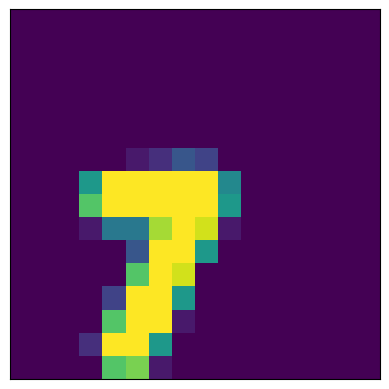

In [13]:
plotImage(dataset[0]["features"])

In [14]:
print(dataset)

[{'features': array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,
        3,  5,  4,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  9, 16, 16, 16,
       16, 16,  8,  1,  1,  1,  1,  1,  1,  1,  1,  1, 12, 16, 16, 16, 16,
       16,  9,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  7,  7, 14, 16, 15,
        2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  5, 16, 16,  9,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 12, 16, 15,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  4, 16, 16,  9,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, 12, 16, 16,  2,  1,  1,  1,  1,  1,
        1, 

In [ ]:
np.savez("data/training_data.npz", features=X, labels=y)